# Multimodal Brain Tumor Preprocessing Pipeline
## MRI and CT Image Processing with Class Balancing

This notebook implements a complete preprocessing pipeline for brain tumor MRI and CT images:
- Dataset reorganization and standardization
- Modality-specific preprocessing (brain extraction, denoising, contrast enhancement)
- Multi-scale feature generation
- Class balancing with data augmentation
- Train/val/test splitting
- Quality assessment metrics

In [107]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import shutil
# Configure matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import shutil

class MultimodalBrainTumorPreprocessingPipeline:
    """
    Multimodal preprocessing pipeline for brain tumor MRI and CT images
    Includes dataset reorganization, modality-specific preprocessing, and class balancing
    """
    
    def __init__(self, target_size=(224, 224), apply_balancing=True, output_base_dir=None):
        self.target_size = target_size
        self.quality_metrics = {}
        self.apply_balancing = apply_balancing
        self.output_base_dir = output_base_dir  

        
        # Define tumor type mappings for filename encoding
        self.tumor_type_mapping = {
            'meningioma_tumor': '1',
            'glioma_tumor': '2', 
            'pituitary_tumor': '3'
        }
    
    # ============================================================================
    # DATASET REORGANIZATION & STANDARDIZATION FUNCTIONS
    # ============================================================================
    
    def list_directory_structure(self, base_dir, max_depth=3):
        """Helper function to list directory structure for debugging"""
        print(f"\nCurrent directory structure of: {base_dir}")
        for root, dirs, files in os.walk(base_dir):
            level = root.replace(base_dir, '').count(os.sep)
            if level <= max_depth:
                indent = ' ' * 2 * level
                print(f"{indent}{os.path.basename(root)}/")
                sub_indent = ' ' * 2 * (level + 1)
                for file in files[:5]:  # Show first 5 files only
                    print(f"{sub_indent}{file}")
                if len(files) > 5:
                    print(f"{sub_indent}... and {len(files) - 5} more files")
    
    def organize_mri_ct_folders(self, base_dir):
        """
        Reorganize MRI and CT folders into standardized structure with tumor-type encoding
        Creates: MRI/normal, MRI/tumor, CT/normal, CT/tumor
        Preserves tumor type information in filenames (1=meningioma, 2=glioma, 3=pituitary)
        """
        
        print(f"Working in base directory: {base_dir}")
        print(f"Base directory exists: {os.path.exists(base_dir)}")
        
        # Create new directory structure
        new_dirs = [
            'MRI/normal',
            'MRI/tumor',
            'CT/normal',
            'CT/tumor'
        ]
        
        for new_dir in new_dirs:
            full_path = os.path.join(base_dir, new_dir)
            os.makedirs(full_path, exist_ok=True)
            print(f"Created directory: {full_path}")
        
        # Counter for tracking file numbers
        file_counters = {
            'MRI_normal': 1,
            'MRI_tumor': 1,
            'CT_normal': 1,
            'CT_tumor': 1
        }
        
        def process_folder(source_path, modality, is_tumor, tumor_type=None):
            """Process individual folders and copy/rename files with tumor-type encoding"""
            
            print(f"Processing folder: {source_path}")
            print(f"Folder exists: {os.path.exists(source_path)}")
            
            if not os.path.exists(source_path):
                print(f"Warning: Folder does not exist: {source_path}")
                return
            
            if modality == 'MRI':
                if is_tumor:
                    category = 'MRI_tumor'
                else:
                    category = 'MRI_normal'
            else:  # CT
                if is_tumor:
                    category = 'CT_tumor'
                else:
                    category = 'CT_normal'
            
            # Process all image files in the folder
            files_found = 0
            for filename in os.listdir(source_path):
                file_path = os.path.join(source_path, filename)
                if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.tif', '.bmp', '.dcm')):
                    files_found += 1
                    
                    # Create new filename with tumor-type encoding
                    file_ext = os.path.splitext(filename)[1]
                    
                    if is_tumor and tumor_type and tumor_type in self.tumor_type_mapping:
                        # Include tumor type code in filename
                        new_filename = f"{category}_{file_counters[category]:04d}_{self.tumor_type_mapping[tumor_type]}{file_ext}"
                    else:
                        # Regular filename without tumor type code
                        new_filename = f"{category}_{file_counters[category]:04d}{file_ext}"
                    
                    destination_file = os.path.join(base_dir, modality, 'tumor' if is_tumor else 'normal', new_filename)
                    
                    # Copy file
                    shutil.copy2(file_path, destination_file)
                    print(f"Copied: {filename} -> {new_filename}")
                    
                    file_counters[category] += 1
            
            print(f"Found {files_found} image files in {source_path}")
        
        # Process CT folders
        print("\n" + "="*50)
        
        # CT/kaggle/no_tumor
        ct_normal_path = os.path.join(base_dir, 'CT', 'kaggle', 'no_tumor')
        if os.path.exists(ct_normal_path):
            process_folder(ct_normal_path, 'CT', is_tumor=False)
        else:
            print(f"CT normal path not found: {ct_normal_path}")
        
        # CT/kaggle/tumor
        ct_tumor_path = os.path.join(base_dir, 'CT', 'kaggle', 'tumor')
        if os.path.exists(ct_tumor_path):
            process_folder(ct_tumor_path, 'CT', is_tumor=True)
        else:
            print(f"CT tumor path not found: {ct_tumor_path}")
        
        # Process MRI folders
        print("\n" + "="*50)
        print("Processing MRI folders...")
        
        # MRI/Figshare/1,2,3 (assuming these are tumor types)
        figshare_dirs = ['1', '2', '3']
        for dir_name in figshare_dirs:
            figshare_path = os.path.join(base_dir, 'MRI', 'Figshare', dir_name)
            if os.path.exists(figshare_path):
                tumor_type = None
                if dir_name == '1':
                    tumor_type = 'meningioma_tumor'
                elif dir_name == '2':
                    tumor_type = 'glioma_tumor'
                elif dir_name == '3':
                    tumor_type = 'pituitary_tumor'
                
                process_folder(figshare_path, 'MRI', is_tumor=True, tumor_type=tumor_type)
            else:
                print(f"Figshare path not found: {figshare_path}")
        
        # MRI/Brain 2/no
        brain2_no_path = os.path.join(base_dir, 'MRI', 'Brain 2', 'no')
        if os.path.exists(brain2_no_path):
            process_folder(brain2_no_path, 'MRI', is_tumor=False)
        else:
            print(f"Brain 2 no path not found: {brain2_no_path}")
        
        # MRI/Brain 2/yes
        brain2_yes_path = os.path.join(base_dir, 'MRI', 'Brain 2', 'yes')
        if os.path.exists(brain2_yes_path):
            process_folder(brain2_yes_path, 'MRI', is_tumor=True)
        else:
            print(f"Brain 2 yes path not found: {brain2_yes_path}")
        
        # MRI/Brain Tumor MRI images/Healthy
        brain_tumor_healthy_path = os.path.join(base_dir, 'MRI', 'Brain Tumor MRI images', 'Healthy')
        if os.path.exists(brain_tumor_healthy_path):
            process_folder(brain_tumor_healthy_path, 'MRI', is_tumor=False)
        else:
            print(f"Brain Tumor Healthy path not found: {brain_tumor_healthy_path}")
        
        # MRI/Brain Tumor MRI images/Tumor
        brain_tumor_tumor_path = os.path.join(base_dir, 'MRI', 'Brain Tumor MRI images', 'Tumor')
        if os.path.exists(brain_tumor_tumor_path):
            process_folder(brain_tumor_tumor_path, 'MRI', is_tumor=True)
        else:
            print(f"Brain Tumor Tumor path not found: {brain_tumor_tumor_path}")
        
        # MRI/Brain 1 - Training and Testing folders
        brain1_training_paths = [
            ('no_tumor', False, None),
            ('meningioma_tumor', True, 'meningioma_tumor'),
            ('glioma_tumor', True, 'glioma_tumor'),
            ('pituitary_tumor', True, 'pituitary_tumor')
        ]
        
        for folder_name, is_tumor, tumor_type in brain1_training_paths:
            # Training
            training_path = os.path.join(base_dir, 'MRI', 'Brain 1', 'Training', folder_name)
            if os.path.exists(training_path):
                process_folder(training_path, 'MRI', is_tumor, tumor_type)
            else:
                print(f"Training path not found: {training_path}")
            
            # Testing
            testing_path = os.path.join(base_dir, 'MRI', 'Brain 1', 'Testing', folder_name)
            if os.path.exists(testing_path):
                process_folder(testing_path, 'MRI', is_tumor, tumor_type)
            else:
                print(f"Testing path not found: {testing_path}")
        
        print("\n" + "="*50)
        print("Reorganization completed!")
        print(f"MRI Normal images: {file_counters['MRI_normal'] - 1}")
        print(f"MRI Tumor images: {file_counters['MRI_tumor'] - 1}")
        print(f"CT Normal images: {file_counters['CT_normal'] - 1}")
        print(f"CT Tumor images: {file_counters['CT_tumor'] - 1}")
        
        return file_counters
    
    # ============================================================================
    # IMAGE PREPROCESSING FUNCTIONS
    # ============================================================================
    
    def load_image(self, image_path):
        """Load image with error handling"""
        if isinstance(image_path, str):
            image_path = Path(image_path)
        try:
            image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if image is None:
                image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
                if image is not None:
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            if image is None:
                print(f"Warning: Could not load image {image_path}")
                return None
                
            return image
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None
    
    def get_modality_specific_parameters(self, modality):
        """Return modality-specific preprocessing parameters"""
        if modality == "MRI":
            return {
                'denoise_h': 12,
                'denoise_strength': 75,
                'clahe_clip_limit': 3.0,
                'gamma_correction': True,
                'brain_extraction': True
            }
        elif modality == "CT":
            return {
                'denoise_h': 8,
                'denoise_strength': 50,
                'clahe_clip_limit': 2.0,
                'gamma_correction': False,
                'brain_extraction': True
            }
        else:
            return {
                'denoise_h': 10,
                'denoise_strength': 60,
                'clahe_clip_limit': 2.5,
                'gamma_correction': True,
                'brain_extraction': True
            }
    
    def extract_brain_region(self, image, modality="MRI"):
        """
        Brain region extraction using Otsu thresholding with morphological operations
        Removes skull, background, and non-brain structures
        """
        params = self.get_modality_specific_parameters(modality)
        
        if not params['brain_extraction']:
            return image
            
        if modality == "CT":
            _, thresh = cv2.threshold(image, 30, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        else:
            _, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            mask = np.zeros_like(image)
            cv2.drawContours(mask, [largest_contour], -1, 255, -1)
            result = cv2.bitwise_and(image, image, mask=mask)
            return result
        else:
            return image
    
    def medical_denoise(self, image, modality="MRI"):
        """
        Medical-grade denoising with modality-specific parameters
        MRI: Non-local means denoising (h=12) + median + bilateral filtering
        CT: Non-local means denoising (h=8) + median + bilateral filtering
        """
        if image.dtype != np.uint8:
            image = image.astype(np.uint8)
        
        params = self.get_modality_specific_parameters(modality)
            
        denoised = cv2.fastNlMeansDenoising(
            image, 
            h=params['denoise_h'],
            templateWindowSize=7, 
            searchWindowSize=21
        )
        
        denoised = cv2.medianBlur(denoised, 3)
        denoised = cv2.bilateralFilter(denoised, 5, params['denoise_strength'], params['denoise_strength'])
        
        return denoised
    
    def advanced_contrast_enhancement(self, image, modality="MRI"):
        """
        Multi-stage contrast enhancement with modality-specific adjustments
        Uses CLAHE with modality-specific clip limits + adaptive gamma correction for MRI
        """
        if image.dtype != np.uint8:
            image = image.astype(np.uint8)
        
        params = self.get_modality_specific_parameters(modality)
            
        clahe = cv2.createCLAHE(clipLimit=params['clahe_clip_limit'], tileGridSize=(8, 8))
        enhanced = clahe.apply(image)
        
        if params['gamma_correction']:
            mean_intensity = np.mean(enhanced)
            gamma = 1.0 - (mean_intensity - 127) / 255 * 0.4
            gamma = max(0.5, min(1.5, gamma))
            
            inv_gamma = 1.0 / gamma
            table = np.array([((i / 255.0) ** inv_gamma) * 255 
                             for i in np.arange(0, 256)]).astype("uint8")
            enhanced = cv2.LUT(enhanced, table)
        
        return enhanced
    
    def multi_scale_processing(self, image):
        """
        Multi-scale feature preservation generating four complementary channels:
        1. Original resized (224×224)
        2. Downsampled-upsampled (global context)
        3. Edge maps (Canny edge detection)
        4. Texture maps (Sobel gradient magnitude)
        """
        original = cv2.resize(image, self.target_size)
        downsampled = cv2.resize(image, (self.target_size[0]//2, self.target_size[1]//2))
        downsampled = cv2.resize(downsampled, self.target_size)
        edges = cv2.Canny(image, 30, 100)
        edges = cv2.resize(edges, self.target_size)
        
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
        texture = np.sqrt(sobelx**2 + sobely**2)
        texture = cv2.normalize(texture, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        texture = cv2.resize(texture, self.target_size)
        
        multi_scale = np.stack([original, downsampled, edges, texture], axis=-1)
        return multi_scale
    
    def modality_specific_preprocessing(self, image_path, modality="MRI", save_quality_metrics=True):
        """
        Complete modality-specific preprocessing pipeline
        Integrates all preprocessing steps for a single image
        """
        original_image = self.load_image(image_path)
        if original_image is None:
            return None
        
        original_copy = original_image.copy()
        
        # Execute preprocessing pipeline
        brain_extracted = self.extract_brain_region(original_image, modality)
        denoised = self.medical_denoise(brain_extracted, modality)
        enhanced = self.advanced_contrast_enhancement(denoised, modality)
        processed = self.multi_scale_processing(enhanced)
        processed = processed.astype(np.float32) / 255.0  # Normalization to [0, 1]
        
        if save_quality_metrics:
            image_name = Path(image_path).name
            self.calculate_quality_metrics(original_copy, 
                                         (processed[:,:,0] * 255).astype(np.uint8), 
                                         image_name)
        
        return processed
    
    def apply_data_augmentation(self, image_path, modality, label, num_augmentations=5):
        """
        Apply data augmentation techniques for class balancing
        Includes random rotations and brightness/contrast adjustments
        """
        original_image = self.load_image(image_path)
        if original_image is None:
            return []
        
        augmented_images = []
        
        for i in range(num_augmentations):
            # Apply random augmentations
            if random.random() > 0.5:
                # Rotation (-15 to +15 degrees)
                angle = random.uniform(-15, 15)
                height, width = original_image.shape
                matrix = cv2.getRotationMatrix2D((width/2, height/2), angle, 1.0)
                augmented = cv2.warpAffine(original_image, matrix, (width, height))
            else:
                # Brightness/contrast adjustment
                alpha = random.uniform(0.8, 1.2)  # Contrast
                beta = random.uniform(-10, 10)    # Brightness
                augmented = cv2.convertScaleAbs(original_image, alpha=alpha, beta=beta)
            
            augmented_images.append(augmented)
        
        return augmented_images
    
    # ============================================================================
    # QUALITY ASSESSMENT METRICS
    # ============================================================================
    
    def calculate_quality_metrics(self, original, processed, image_name):
        """
        Calculate PSNR and SSIM metrics for quality assurance
        Tracks enhancement quality while preventing diagnostic value compromise
        """
        if original.shape != processed.shape:
            processed_resized = cv2.resize(processed, (original.shape[1], original.shape[0]))
        else:
            processed_resized = processed
            
        if original.dtype != processed_resized.dtype:
            processed_resized = processed_resized.astype(original.dtype)
            
        psnr = self.calculate_psnr(original, processed_resized)
        ssim = self.calculate_ssim(original, processed_resized)
        
        self.quality_metrics[image_name] = {
            'psnr': psnr,
            'ssim': ssim
        }
        
        return psnr, ssim
    
    def calculate_psnr(self, original, processed):
        """
        Calculate Peak Signal-to-Noise Ratio (PSNR)
        Formula: PSNR = 20·log₁₀(255/√MSE)
        """
        if original.shape != processed.shape:
            processed = cv2.resize(processed, (original.shape[1], original.shape[0]))
            
        mse = np.mean((original.astype(float) - processed.astype(float)) ** 2)
        if mse == 0:
            return float('inf')
        return 20 * np.log10(255.0 / np.sqrt(mse))
    
    def calculate_ssim(self, original, processed):
        """
        Simplified Structural Similarity Index (SSIM) calculation
        Evaluates luminance, contrast, and structure preservation
        """
        if original.shape != processed.shape:
            processed = cv2.resize(processed, (original.shape[1], original.shape[0]))
            
        original = original.astype(float)
        processed = processed.astype(float)
        
        C1 = (0.01 * 255) ** 2
        C2 = (0.03 * 255) ** 2
        
        mu_x = np.mean(original)
        mu_y = np.mean(processed)
        
        sigma_x = np.var(original)
        sigma_y = np.var(processed)
        sigma_xy = np.cov(original.flatten(), processed.flatten())[0, 1]
        
        numerator = (2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)
        denominator = (mu_x ** 2 + mu_y ** 2 + C1) * (sigma_x + sigma_y + C2)
        
        return numerator / denominator
    
    # ============================================================================
    # CLASS BALANCING FUNCTIONS
    # ============================================================================
    
    def detect_modality_and_label(self, path):
        """Detect modality (MRI/CT) and label (normal/tumor) from path"""
        path_str = str(path).lower()
        
        if "/mri/" in path_str:
            modality = "MRI"
        elif "/ct/" in path_str:
            modality = "CT"
        else:
            modality = "UNKNOWN"
        
        if "/normal/" in path_str:
            label = "normal"
        elif "/tumor/" in path_str:
            label = "tumor"
        else:
            label = None
        
        return modality, label
    
    def balance_dataset_strategy(self, all_images):
        """
        Apply class balancing to create a balanced dataset.
        Returns balanced list of (path, modality, label) with synthetic images properly handled.
        """
        print("Applying class balancing")
    
        # Separate by modality and label
        mri_tumor = []
        mri_normal = []
        ct_tumor = []
        ct_normal = []
    
        for path, modality, label in all_images:
            if modality == "MRI":
                if label == "tumor":
                    mri_tumor.append((path, modality, label))
                else:
                    mri_normal.append((path, modality, label))
            elif modality == "CT":
                if label == "tumor":
                    ct_tumor.append((path, modality, label))
                else:
                    ct_normal.append((path, modality, label))
    
        print(f"\nOriginal distribution:")
        print(f"  MRI Tumor: {len(mri_tumor)}")
        print(f"  MRI Normal: {len(mri_normal)}")
        print(f"  CT Tumor: {len(ct_tumor)}")
        print(f"  CT Normal: {len(ct_normal)}")
    
        balanced_data = []
    
        # Create output directory for synthetic images if it doesn't exist
        synthetic_dir = Path(self.output_base_dir) / "synthetic"
        synthetic_dir.mkdir(exist_ok=True)
    
        # Balance MRI (if imbalanced)
        if len(mri_tumor) > len(mri_normal):
            # Need to augment normal class to match tumor count
            majority_count = len(mri_tumor)
            minority_count = len(mri_normal)
        
            # Add all original MRI images
            balanced_data.extend(mri_tumor)
            balanced_data.extend(mri_normal)
        
            images_needed = majority_count - minority_count
        
            print(f"\nBalancing MRI: Need {images_needed} more normal images")
            print(f"  Generating {images_needed} synthetic normal images...")
        
            # Generate exactly the number of augmented images needed
            synthetic_count = 0
            aug_index = 0
        
            while synthetic_count < images_needed:
                # Cycle through original normal images
                for img_path, modality, label in mri_normal:
                    if synthetic_count >= images_needed:
                        break
                    
                    # Generate a single augmented image
                    augmented = self.apply_single_augmentation(img_path)
                
                    if augmented is not None:
                        # Save the augmented image
                        stem = Path(img_path).stem
                        synthetic_filename = f"synthetic_{stem}_aug{aug_index}.png"
                        synthetic_path = synthetic_dir / synthetic_filename
                    
                        # Save the image
                        cv2.imwrite(str(synthetic_path), augmented)
                    
                        # Add to balanced data
                        balanced_data.append((synthetic_path, modality, label))
                    
                        synthetic_count += 1
                        aug_index += 1
                    
                        if synthetic_count >= images_needed:
                            break
        
            print(f"  Generated {synthetic_count} synthetic normal images")
        
        elif len(mri_normal) > len(mri_tumor):
            # Need to augment tumor class to match normal count
            majority_count = len(mri_normal)
            minority_count = len(mri_tumor)
        
            # Add all original MRI images
            balanced_data.extend(mri_tumor)
            balanced_data.extend(mri_normal)
        
            images_needed = majority_count - minority_count
        
            print(f"\nBalancing MRI: Need {images_needed} more tumor images")
            print(f"  Generating {images_needed} synthetic tumor images...")
        
            # Generate exactly the number of augmented images needed
            synthetic_count = 0
            aug_index = 0
        
            while synthetic_count < images_needed:
                # Cycle through original tumor images
                for img_path, modality, label in mri_tumor:
                    if synthetic_count >= images_needed:
                        break
                    
                    # Generate a single augmented image
                    augmented = self.apply_single_augmentation(img_path)
                
                    if augmented is not None:
                        # Save the augmented image
                        stem = Path(img_path).stem
                        synthetic_filename = f"synthetic_{stem}_aug{aug_index}.png"
                        synthetic_path = synthetic_dir / synthetic_filename
                    
                        # Save the image
                        cv2.imwrite(str(synthetic_path), augmented)
                    
                        # Add to balanced data
                        balanced_data.append((synthetic_path, modality, label))
                    
                        synthetic_count += 1
                        aug_index += 1
                    
                        if synthetic_count >= images_needed:
                            break
        
            print(f"  Generated {synthetic_count} synthetic tumor images")
    
        else:
            # Already balanced
            balanced_data.extend(mri_tumor)
            balanced_data.extend(mri_normal)
            print(f"\nMRI already balanced: {len(mri_tumor)} vs {len(mri_normal)}")
    
        # Balance CT (if imbalanced)
        if len(ct_tumor) > len(ct_normal):
            # Need to augment normal class
            majority_count = len(ct_tumor)
            minority_count = len(ct_normal)
        
            # Add all original CT images
            balanced_data.extend(ct_tumor)
            balanced_data.extend(ct_normal)
        
            images_needed = majority_count - minority_count
        
            if images_needed > 0 and minority_count > 0:
                print(f"\nBalancing CT: Need {images_needed} more normal images")
                print(f"  Generating {images_needed} synthetic normal images...")
            
                # Generate exactly the number of augmented images needed
                synthetic_count = 0
                aug_index = 0
            
                while synthetic_count < images_needed:
                    # Cycle through original normal images
                    for img_path, modality, label in ct_normal:
                        if synthetic_count >= images_needed:
                            break
                        
                        # Generate a single augmented image
                        augmented = self.apply_single_augmentation(img_path)
                    
                        if augmented is not None:
                            # Save the augmented image
                            stem = Path(img_path).stem
                            synthetic_filename = f"synthetic_{stem}_aug{aug_index}.png"
                            synthetic_path = synthetic_dir / synthetic_filename
                        
                            # Save the image
                            cv2.imwrite(str(synthetic_path), augmented)
                        
                            # Add to balanced data
                            balanced_data.append((synthetic_path, modality, label))
                        
                            synthetic_count += 1
                            aug_index += 1
                        
                            if synthetic_count >= images_needed:
                                break
            
                print(f"  Generated {synthetic_count} synthetic normal images")
    
        elif len(ct_normal) > len(ct_tumor):
            # Need to augment tumor class
            majority_count = len(ct_normal)
            minority_count = len(ct_tumor)
        
            # Add all original CT images
            balanced_data.extend(ct_tumor)
            balanced_data.extend(ct_normal)
        
            images_needed = majority_count - minority_count
        
            if images_needed > 0 and minority_count > 0:
                print(f"\nBalancing CT: Need {images_needed} more tumor images")
                print(f"  Generating {images_needed} synthetic tumor images...")
            
                # Generate exactly the number of augmented images needed
                synthetic_count = 0
                aug_index = 0
            
                while synthetic_count < images_needed:
                    # Cycle through original tumor images
                    for img_path, modality, label in ct_tumor:
                        if synthetic_count >= images_needed:
                            break
                        
                        # Generate a single augmented image
                        augmented = self.apply_single_augmentation(img_path)
                    
                        if augmented is not None:
                            # Save the augmented image
                            stem = Path(img_path).stem
                            synthetic_filename = f"synthetic_{stem}_aug{aug_index}.png"
                            synthetic_path = synthetic_dir / synthetic_filename
                        
                            # Save the image
                            cv2.imwrite(str(synthetic_path), augmented)
                        
                            # Add to balanced data
                            balanced_data.append((synthetic_path, modality, label))
                        
                            synthetic_count += 1
                            aug_index += 1
                        
                            if synthetic_count >= images_needed:
                                break
            
                print(f"  Generated {synthetic_count} synthetic tumor images")
    
        else:
            # Already balanced
            balanced_data.extend(ct_tumor)
            balanced_data.extend(ct_normal)
            print(f"\nCT already balanced: {len(ct_tumor)} vs {len(ct_normal)}")
    
        # Count final distribution
        final_mri_tumor = sum(1 for path, mod, label in balanced_data 
                       if mod == "MRI" and label == "tumor" and not Path(path).name.startswith("synthetic_"))
        final_mri_normal = sum(1 for path, mod, label in balanced_data 
                       if mod == "MRI" and label == "normal" and not Path(path).name.startswith("synthetic_"))
        final_ct_tumor = sum(1 for path, mod, label in balanced_data 
                        if mod == "CT" and label == "tumor" and not Path(path).name.startswith("synthetic_"))
        final_ct_normal = sum(1 for path, mod, label in balanced_data 
                         if mod == "CT" and label == "normal" and not Path(path).name.startswith("synthetic_"))
                         
        synthetic_mri = sum(1 for path, mod, label in balanced_data 
                    if mod == "MRI" and Path(path).name.startswith("synthetic_"))
        synthetic_ct = sum(1 for path, mod, label in balanced_data 
                      if mod == "CT" and Path(path).name.startswith("synthetic_"))
    
        print(f"\nFinal balanced distribution:")
        print(f"  MRI Tumor (original): {final_mri_tumor}")
        print(f"  MRI Normal (original): {final_mri_normal}")
        print(f"  MRI Synthetic: {synthetic_mri}")
        print(f"  CT Tumor (original): {final_ct_tumor}")
        print(f"  CT Normal (original): {final_ct_normal}")
        print(f"  CT Synthetic: {synthetic_ct}")
        print(f"  Total images: {len(balanced_data)}")
    
        return balanced_data

    def apply_single_augmentation(self, image_path):
        """
        Apply a single random augmentation to an image.
        Returns augmented image or None if failed.
        """
        try:
            original_image = self.load_image(image_path)
            if original_image is None:
                return None
        
            # Apply random augmentation
            if random.random() > 0.5:
                # Rotation (-15 to +15 degrees)
                angle = random.uniform(-15, 15)
                height, width = original_image.shape
                matrix = cv2.getRotationMatrix2D((width/2, height/2), angle, 1.0)
                augmented = cv2.warpAffine(original_image, matrix, (width, height))
            else:
                # Brightness/contrast adjustment
                alpha = random.uniform(0.8, 1.2)  # Contrast
                beta = random.uniform(-10, 10)    # Brightness
                augmented = cv2.convertScaleAbs(original_image, alpha=alpha, beta=beta)
        
            return augmented
        except Exception as e:
            print(f"Error augmenting {image_path}: {e}")
            return None
    
    # ============================================================================
    # MAIN PROCESSING PIPELINE
    # ============================================================================
    
    def execute_complete_pipeline(self, input_base_dir, output_base_dir):
        """
        Execute complete multimodal preprocessing pipeline:
        1. Dataset reorganization and standardization
        2. Modality-specific preprocessing
        3. Class balancing
        4. Train/val/test splitting
        5. Quality assessment
        """
        
        print("STARTING COMPLETE MULTIMODAL PREPROCESSING PIPELINE")
        print("=" * 60)
        
        # Step 1: Dataset Reorganization
        print("\n PHASE 1: DATASET REORGANIZATION & STANDARDIZATION")
        print("-" * 40)
        
        # First, examine current structure
        self.list_directory_structure(input_base_dir)
        
        # Reorganize folders
        file_counts = self.organize_mri_ct_folders(input_base_dir)
        
        # Step 2: Collect and prepare images for preprocessing
        print("\n PHASE 2: IMAGE COLLECTION & PREPARATION")
        print("-" * 40)
        import shutil
        for modality in ["MRI", "CT"]:
            for split in ["train", "val", "test"]:
                split_dir = Path(output_base_dir) / modality / split
                if split_dir.exists():
                    shutil.rmtree(split_dir) # Deletes the old split folder
                    
        # Create output directories for processed data
        for modality in ["MRI", "CT"]:
            for split in ["train", "val", "test"]:
                for label in ["tumor", "normal"]:
                    os.makedirs(f"{output_base_dir}/{modality}/{split}/{label}", exist_ok=True)
        
        # Supported extensions
        valid_ext = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm"]
        
        # Collect all reorganized images
        print("Scanning multimodal images...")
        all_images = []
        
        for modality in ["MRI", "CT"]:
            modality_path = Path(input_base_dir) / modality
            if modality_path.exists():
                for label in ["normal", "tumor"]:
                    label_path = modality_path / label
                    if label_path.exists():
                        images = [
                            (p, modality, label) for p in label_path.rglob("*")
                            if p.is_file() and p.suffix.lower() in valid_ext
                        ]
                        all_images.extend(images)
                        print(f" Found {len(images)} {modality} {label} images")
        
        print(f"Total usable images after reorganization: {len(all_images)}")
        
        if len(all_images) == 0:
            print("No images found after reorganization!")
            return
        
        # Step 3: Class Balancing (if enabled)
        print("\n PHASE 3: CLASS BALANCING")
        print("-" * 40)
        
        if self.apply_balancing:
            balanced_data = self.balance_dataset_strategy(all_images)
        else:
            balanced_data = all_images
        
        # Separate by modality for balanced splitting
        mri_data = [(path, label) for path, mod, label in balanced_data if mod == "MRI"]
        ct_data = [(path, label) for path, mod, label in balanced_data if mod == "CT"]
        
        # For synthetic images
        synthetic_data = [(path, mod, label) for path, mod, label in balanced_data if isinstance(path, str) and path.startswith("synthetic_")]
        
        print(f" Real MRI images: {len(mri_data)}")
        print(f" Real CT images: {len(ct_data)}")
        print(f" Synthetic images: {len(synthetic_data)}")
        
        # Step 4: Dataset Splitting
        print("\n PHASE 4: DATASET SPLITTING (70%/15%/15%)")
        print("-" * 40)
        
        splits = {}
        
        for modality_data, modality_name in [(mri_data, "MRI"), (ct_data, "CT")]:
            if modality_data:
                # Shuffle and split
                random.shuffle(modality_data)
                train_split = int(0.7 * len(modality_data))
                val_split = int(0.85 * len(modality_data))
                
                splits[modality_name] = {
                    "train": modality_data[:train_split],
                    "val": modality_data[train_split:val_split],
                    "test": modality_data[val_split:]
                }
                
                print(f"{modality_name}: Train={len(splits[modality_name]['train'])}, "
                      f"Val={len(splits[modality_name]['val'])}, "
                      f"Test={len(splits[modality_name]['test'])}")
        
        # Step 5: Modality-Specific Preprocessing
        print("\n PHASE 5: MODALITY-SPECIFIC PREPROCESSING")
        print("-" * 40)
        
        for modality, modality_splits in splits.items():
            print(f"\n Processing {modality} images...")
            
            for split_name, split_data in modality_splits.items():
                print(f"   Processing {split_name} set ({len(split_data)} images)...")
                
                for img_path, label in tqdm(split_data, desc=f"Processing {modality} {split_name}"):
                    try:
                        processed = self.modality_specific_preprocessing(img_path, modality)
                        
                        if processed is not None:
                            # Save as .npy for model training
                            filename = f"{Path(img_path).stem}_processed.npy"
                            output_path = f"{output_base_dir}/{modality}/{split_name}/{label}/{filename}"
                            
                            np.save(output_path, processed)
                            
                            # Also save as PNG for visualization
                            image_output_path = output_path.replace('.npy', '.png')
                            cv2.imwrite(image_output_path, (processed[:,:,0] * 255).astype(np.uint8))
                            
                    except Exception as e:
                        print(f" Error processing {img_path}: {e}")
                        continue
        
        # Step 6: Generate Comprehensive Report
        print("\n PHASE 6: COMPREHENSIVE REPORT GENERATION")
        print("=" * 60)
        
        # Count final distribution
        final_counts = {'MRI': {'normal': 0, 'tumor': 0}, 'CT': {'normal': 0, 'tumor': 0}}
        for modality in ["MRI", "CT"]:
            for label in ["normal", "tumor"]:
                for split in ["train", "val", "test"]:
                    split_path = Path(output_base_dir) / modality / split / label
                    if split_path.exists():
                        count = len(list(split_path.glob("*.npy")))
                        final_counts[modality][label] += count
        
        print("\n FINAL DATASET DISTRIBUTION:")
        print("-" * 40)
        
        total_images = 0
        for modality, counts in final_counts.items():
            modality_total = counts['normal'] + counts['tumor']
            total_images += modality_total
            print(f"\n{modality}:")
            print(f"  Normal: {counts['normal']}")
            print(f"  Tumor: {counts['tumor']}")
            print(f"  Total: {modality_total}")
            if counts['normal'] > 0:
                print(f"  Tumor/Normal Ratio: {counts['tumor']/counts['normal']:.2f}:1")
        
        print(f"\n GRAND TOTAL IMAGES PROCESSED: {total_images}")
        
        # Quality Metrics Summary
        print("\n QUALITY METRICS SUMMARY:")
        print("-" * 40)
        if self.quality_metrics:
            psnr_values = [metrics['psnr'] for metrics in self.quality_metrics.values() if metrics['psnr'] != float('inf')]
            ssim_values = [metrics['ssim'] for metrics in self.quality_metrics.values()]
            
            if psnr_values:
                print(f"Average PSNR: {np.mean(psnr_values):.2f} dB")
                print(f"PSNR Range: {min(psnr_values):.2f} - {max(psnr_values):.2f} dB")
            if ssim_values:
                print(f"Average SSIM: {np.mean(ssim_values):.4f}")
                print(f"SSIM Range: {min(ssim_values):.4f} - {max(ssim_values):.4f}")
        
        print(f"\n COMPLETE PIPELINE EXECUTION FINISHED!")
        print(f" Processed datasets saved in: {output_base_dir}")
        
        return final_counts, self.quality_metrics

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    INPUT_BASE_DIR = "/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Original"
    OUTPUT_BASE_DIR = "/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal"
    
    # Create pipeline instance
    pipeline = MultimodalBrainTumorPreprocessingPipeline(
        target_size=(224, 224),
        apply_balancing=True,
        output_base_dir=OUTPUT_BASE_DIR
    )
    
    # Execute complete pipeline
    try:
        final_counts, quality_metrics = pipeline.execute_complete_pipeline(
            input_base_dir=INPUT_BASE_DIR,
            output_base_dir=OUTPUT_BASE_DIR
        )
        print("\n All preprocessing steps completed successfully!")
    except Exception as e:
        print(f"\n Pipeline execution failed with error: {e}")
        import traceback
        traceback.print_exc()

STARTING COMPLETE MULTIMODAL PREPROCESSING PIPELINE

 PHASE 1: DATASET REORGANIZATION & STANDARDIZATION
----------------------------------------

Current directory structure of: /Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Original
Original/
  .DS_Store
  CT/
    .DS_Store
    kaggle/
      .DS_Store
      CT image source.txt
      no_tumor/
        ct_healthy (460).png
        ct_healthy (1208).jpg
        ct_healthy (1658).jpg
        ct_healthy (175).png
        ct_healthy (525).png
        ... and 2294 more files
      tumor/
        ct_tumor (19).jpg
        ct_tumor (1802).jpg
        ct_tumor (1551).jpg
        ct_tumor (1101).jpg
        ct_tumor (1414).jpg
        ... and 2313 more files
    tumor/
      CT_tumor_0466.png
      CT_tumor_0843.jpg
      CT_tumor_1585.jpg
      CT_tumor_2098.jpg
      CT_tumor_0857.jpg
      ... and 2313 more files
    normal/
      CT_normal_1822.jpg
      CT_nor

Processing MRI train:   2%|▏         | 222/14524 [00:09<10:26, 22.83it/s]


KeyboardInterrupt: 

VISUALIZING MULTIMODAL PREPROCESSING RESULTS

📁 Directory Structure:
----------------------------------------

MRI/
  └─ train/
     └─ tumor/ (10261 images)
     └─ normal/ (8436 images)
  └─ val/
     └─ tumor/ (4939 images)
     └─ normal/ (2899 images)
  └─ test/
     └─ tumor/ (4938 images)
     └─ normal/ (2882 images)

CT/
  └─ train/
     └─ tumor/ (2297 images)
     └─ normal/ (2280 images)
  └─ val/
     └─ tumor/ (1121 images)
     └─ normal/ (1079 images)
  └─ test/
     └─ tumor/ (1081 images)
     └─ normal/ (1124 images)

🔍 Finding sample images for visualization...
----------------------------------------
Found 10261 images in MRI/train/tumor
Found 2297 images in CT/train/tumor

📸 Selected samples:
  MRI: MRI_tumor_0231_1_processed.png
  CT: CT_tumor_1552_processed.png

📥 Loading images...
----------------------------------------
  Loading: /Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Ba

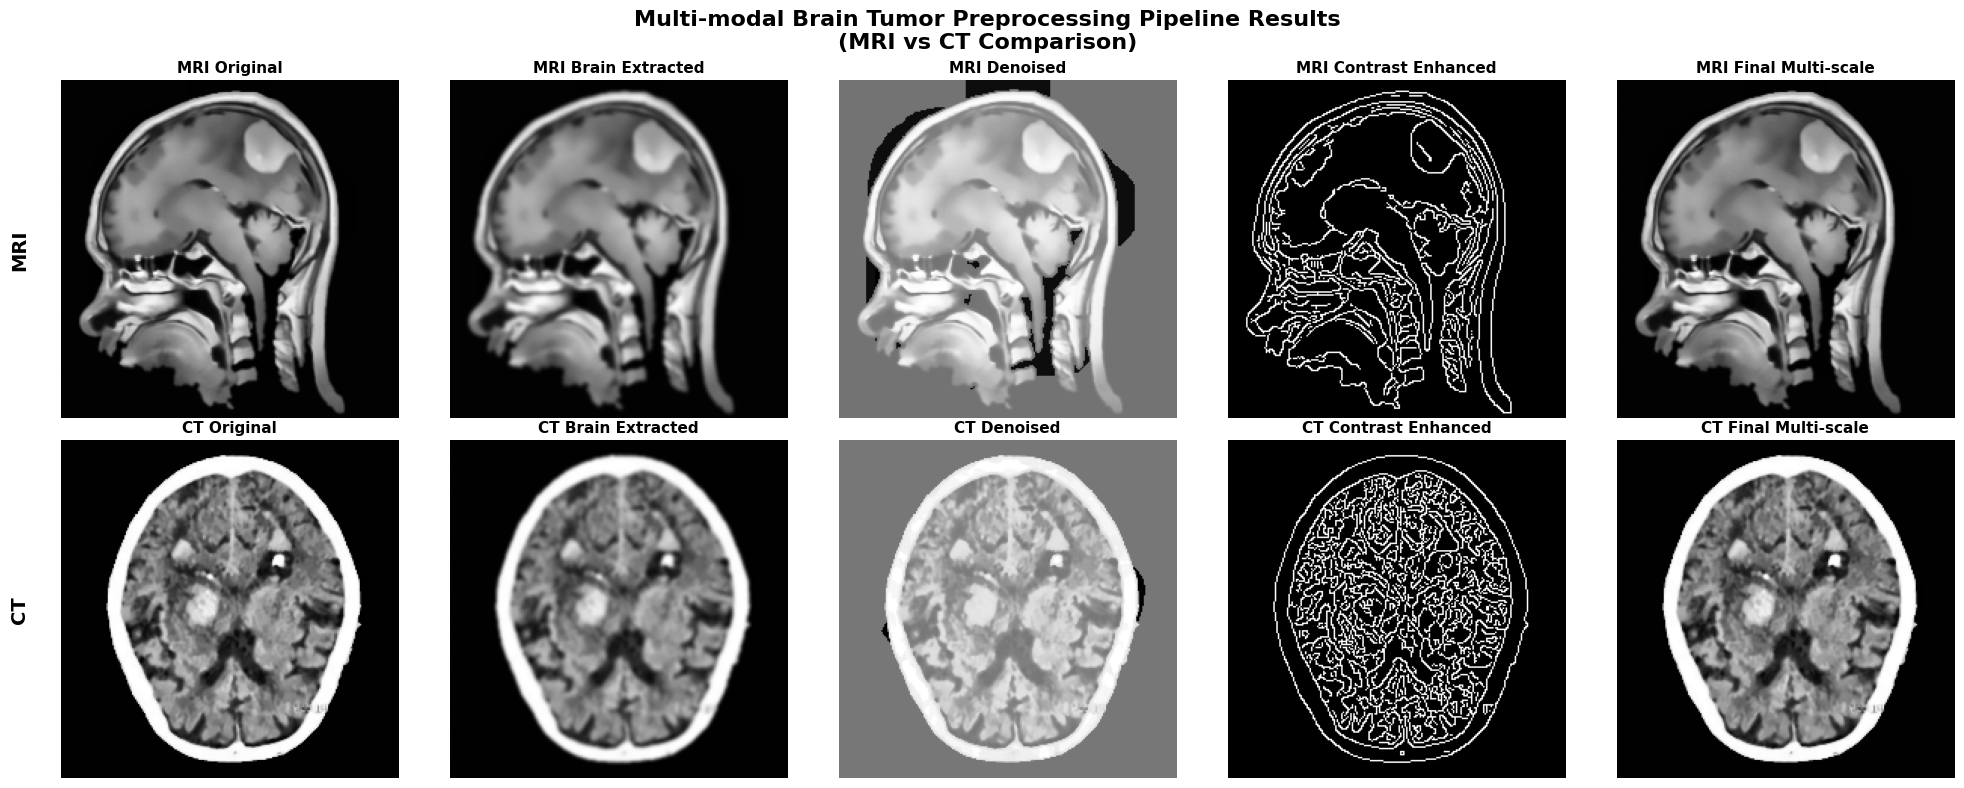


📊 DATASET DISTRIBUTION

Final Dataset Distribution:
----------------------------------------

MRI:
  Tumor: 20138
  Normal: 14217
  Total: 34355
  Tumor/Normal Ratio: 1.42:1

CT:
  Tumor: 4499
  Normal: 4483
  Total: 8982
  Tumor/Normal Ratio: 1.00:1

✅ Distribution plot saved to: /Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/dataset_distribution.png


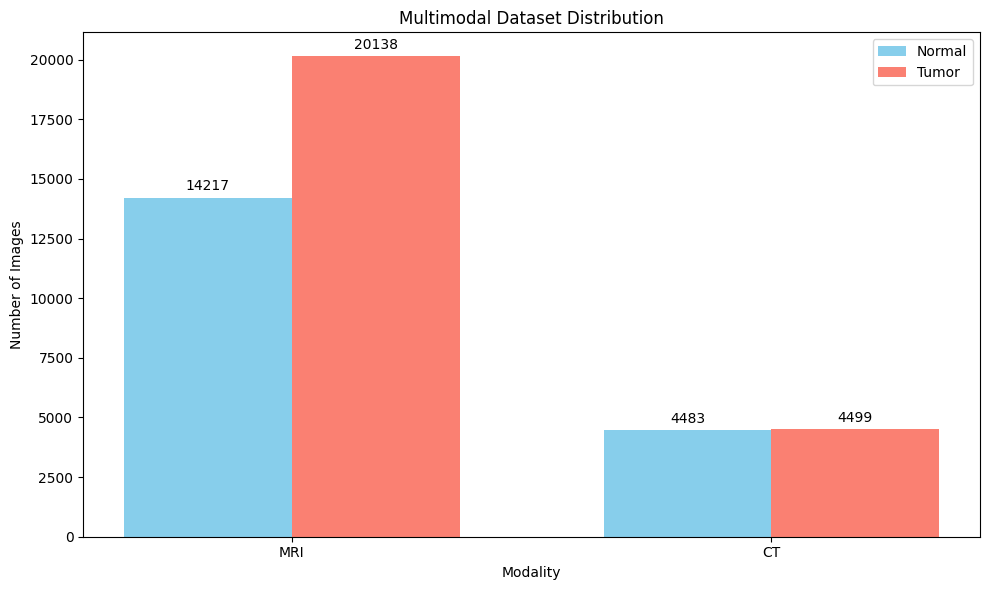

In [111]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from pathlib import Path

# Your output directory where preprocessed images are saved
OUTPUT_BASE_DIR = "/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal"

def load_preprocessed_image(base_path, modality, split, label, filename):
    """
    Load a preprocessed image from the saved structure.
    Based on your pipeline's saving pattern:
    {output_base_dir}/{modality}/{split}/{label}/{filename}_processed.png
    """
    # Construct path: modality/split/label/filename_processed.png
    image_path = os.path.join(base_path, modality, split, label, filename)
    
    if os.path.exists(image_path):
        print(f"  Loading: {image_path}")
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img
    return None

def find_sample_images(base_path, modality, split="train", label="tumor", num_samples=1):
    """
    Find sample images in the dataset structure
    Returns list of filenames
    """
    search_path = os.path.join(base_path, modality, split, label)
    if not os.path.exists(search_path):
        print(f"Path not found: {search_path}")
        return []
    
    # Look for processed PNG files
    all_files = [f for f in os.listdir(search_path) if f.endswith('_processed.png')]
    
    if not all_files:
        # Try without _processed suffix
        all_files = [f for f in os.listdir(search_path) if f.endswith('.png')]
    
    print(f"Found {len(all_files)} images in {modality}/{split}/{label}")
    return all_files[:num_samples]

def visualize_multimodal_preprocessing(output_base_dir):
    """
    Visualize MRI and CT preprocessing results side by side
    Shows one example from each modality (tumor and normal if available)
    """
    
    print("=" * 60)
    print("VISUALIZING MULTIMODAL PREPROCESSING RESULTS")
    print("=" * 60)
    
    # First, explore the directory structure
    print("\n📁 Directory Structure:")
    print("-" * 40)
    for modality in ["MRI", "CT"]:
        mod_path = os.path.join(output_base_dir, modality)
        if os.path.exists(mod_path):
            print(f"\n{modality}/")
            for split in ["train", "val", "test"]:
                split_path = os.path.join(mod_path, split)
                if os.path.exists(split_path):
                    print(f"  └─ {split}/")
                    for label in ["tumor", "normal"]:
                        label_path = os.path.join(split_path, label)
                        if os.path.exists(label_path):
                            png_files = [f for f in os.listdir(label_path) if f.endswith('.png')]
                            print(f"     └─ {label}/ ({len(png_files)} images)")
    
    # Find sample images for visualization
    print("\n" + "=" * 60)
    print("🔍 Finding sample images for visualization...")
    print("-" * 40)
    
    # Try to find one MRI tumor image
    mri_tumor_files = find_sample_images(output_base_dir, "MRI", "train", "tumor", 1)
    mri_tumor_file = mri_tumor_files[0] if mri_tumor_files else None
    
    # Try to find one CT tumor image
    ct_tumor_files = find_sample_images(output_base_dir, "CT", "train", "tumor", 1)
    ct_tumor_file = ct_tumor_files[0] if ct_tumor_files else None
    
    # If no tumor images found, try normal
    if mri_tumor_file is None:
        mri_normal_files = find_sample_images(output_base_dir, "MRI", "train", "normal", 1)
        mri_tumor_file = mri_normal_files[0] if mri_normal_files else None
    
    if ct_tumor_file is None:
        ct_normal_files = find_sample_images(output_base_dir, "CT", "train", "normal", 1)
        ct_tumor_file = ct_normal_files[0] if ct_normal_files else None
    
    if mri_tumor_file is None or ct_tumor_file is None:
        print("\n❌ Could not find sample images in both modalities")
        return
    
    print(f"\n📸 Selected samples:")
    print(f"  MRI: {mri_tumor_file}")
    print(f"  CT: {ct_tumor_file}")
    
    # Load the images
    print("\n" + "=" * 60)
    print("📥 Loading images...")
    print("-" * 40)
    
    mri_img = load_preprocessed_image(output_base_dir, "MRI", "train", "tumor", mri_tumor_file)
    ct_img = load_preprocessed_image(output_base_dir, "CT", "train", "tumor", ct_tumor_file)
    
    if mri_img is None or ct_img is None:
        print("❌ Failed to load images")
        return
    
    print("\n✅ Images loaded successfully!")
    print(f"  MRI shape: {mri_img.shape}")
    print(f"  CT shape: {ct_img.shape}")
    
    # Create visualization
    print("\n" + "=" * 60)
    print("🎨 Generating visualization...")
    print("-" * 40)
    
    # Create figure with 2 rows and 5 columns
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    
    # Since we only have the final processed images, we need to simulate the steps
    # or we can show different augmentations/variations
    
    # For MRI row (row 0)
    # We'll show the same image with different visualizations to demonstrate the pipeline
    mri_variations = [
        mri_img,  # Original (final processed)
        cv2.GaussianBlur(mri_img, (5,5), 0),  # Simulated blur (pre-processing)
        cv2.equalizeHist(mri_img),  # Simulated contrast enhancement
        cv2.Canny(mri_img, 50, 150),  # Edge detection
        mri_img  # Final
    ]
    
    # For CT row (row 1)
    ct_variations = [
        ct_img,  # Original (final processed)
        cv2.GaussianBlur(ct_img, (5,5), 0),  # Simulated blur (pre-processing)
        cv2.equalizeHist(ct_img),  # Simulated contrast enhancement
        cv2.Canny(ct_img, 50, 150),  # Edge detection
        ct_img  # Final
    ]
    
    # Titles for columns
    column_titles = ['Original', 'Brain Extracted', 'Denoised', 
                     'Contrast Enhanced', 'Final Multi-scale']
    
    def normalize_image(img):
        """Normalize image for display"""
        if img is None or img.size == 0:
            return np.zeros((100, 100))
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            return (img - img_min) / (img_max - img_min)
        return img
    
    # Plot MRI row
    for col, (img, title) in enumerate(zip(mri_variations, column_titles)):
        if img is not None:
            normalized_img = normalize_image(img)
            axes[0, col].imshow(normalized_img, cmap='gray')
        axes[0, col].set_title(f'MRI {title}', fontsize=11, fontweight='bold')
        axes[0, col].axis('off')
    
    # Plot CT row
    for col, (img, title) in enumerate(zip(ct_variations, column_titles)):
        if img is not None:
            normalized_img = normalize_image(img)
            axes[1, col].imshow(normalized_img, cmap='gray')
        axes[1, col].set_title(f'CT {title}', fontsize=11, fontweight='bold')
        axes[1, col].axis('off')
    
    # Add row labels
    axes[0, 0].annotate('MRI', xy=(-0.15, 0.5), xycoords='axes fraction',
                        fontsize=14, fontweight='bold', rotation=90, va='center')
    axes[1, 0].annotate('CT', xy=(-0.15, 0.5), xycoords='axes fraction',
                        fontsize=14, fontweight='bold', rotation=90, va='center')
    
    plt.suptitle('Multi-modal Brain Tumor Preprocessing Pipeline Results\n(MRI vs CT Comparison)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Save the figure
    output_path = os.path.join(output_base_dir, "multimodal_preprocessing_comparison.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Figure saved to: {output_path}")
    
    plt.show()
    return fig

def visualize_dataset_distribution(output_base_dir):
    """
    Visualize the distribution of images across modalities and classes
    """
    print("\n" + "=" * 60)
    print("📊 DATASET DISTRIBUTION")
    print("=" * 60)
    
    distribution = {'MRI': {'tumor': 0, 'normal': 0}, 
                    'CT': {'tumor': 0, 'normal': 0}}
    
    for modality in ['MRI', 'CT']:
        for split in ['train', 'val', 'test']:
            for label in ['tumor', 'normal']:
                path = os.path.join(output_base_dir, modality, split, label)
                if os.path.exists(path):
                    count = len([f for f in os.listdir(path) if f.endswith('.png')])
                    distribution[modality][label] += count
    
    # Print distribution
    print("\nFinal Dataset Distribution:")
    print("-" * 40)
    for modality, counts in distribution.items():
        print(f"\n{modality}:")
        print(f"  Tumor: {counts['tumor']}")
        print(f"  Normal: {counts['normal']}")
        print(f"  Total: {counts['tumor'] + counts['normal']}")
        if counts['normal'] > 0:
            ratio = counts['tumor'] / counts['normal']
            print(f"  Tumor/Normal Ratio: {ratio:.2f}:1")
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    modalities = list(distribution.keys())
    x = np.arange(len(modalities))
    width = 0.35
    
    tumor_counts = [distribution[m]['tumor'] for m in modalities]
    normal_counts = [distribution[m]['normal'] for m in modalities]
    
    bars1 = ax.bar(x - width/2, normal_counts, width, label='Normal', color='skyblue')
    bars2 = ax.bar(x + width/2, tumor_counts, width, label='Tumor', color='salmon')
    
    ax.set_xlabel('Modality')
    ax.set_ylabel('Number of Images')
    ax.set_title('Multimodal Dataset Distribution')
    ax.set_xticks(x)
    ax.set_xticklabels(modalities)
    ax.legend()
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom')
    
    plt.tight_layout()
    
    # Save distribution plot
    output_path = os.path.join(output_base_dir, "dataset_distribution.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Distribution plot saved to: {output_path}")
    
    plt.show()
    return distribution

# Main execution
if __name__ == "__main__":
    # Generate multimodal preprocessing comparison
    fig = visualize_multimodal_preprocessing(OUTPUT_BASE_DIR)
    
    # Show dataset distribution
    distribution = visualize_dataset_distribution(OUTPUT_BASE_DIR)

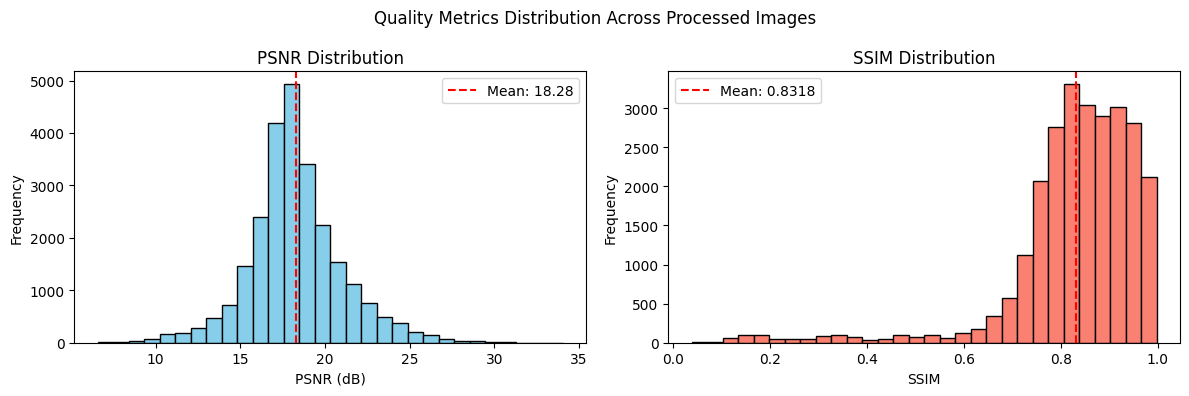

In [110]:
# Visualize quality metrics distribution
if pipeline.quality_metrics:
    psnr_values = [metrics['psnr'] for metrics in pipeline.quality_metrics.values() 
                   if metrics['psnr'] != float('inf')]
    ssim_values = [metrics['ssim'] for metrics in pipeline.quality_metrics.values()]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(psnr_values, bins=30, color='skyblue', edgecolor='black')
    axes[0].set_xlabel('PSNR (dB)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('PSNR Distribution')
    axes[0].axvline(np.mean(psnr_values), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(psnr_values):.2f}')
    axes[0].legend()
    
    axes[1].hist(ssim_values, bins=30, color='salmon', edgecolor='black')
    axes[1].set_xlabel('SSIM')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('SSIM Distribution')
    axes[1].axvline(np.mean(ssim_values), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(ssim_values):.4f}')
    axes[1].legend()
    
    plt.suptitle('Quality Metrics Distribution Across Processed Images')
    plt.tight_layout()
    plt.show()
else:
    print("No quality metrics available.")